## Today's Objectives

By the end of Day 1 you should:

- Understand the full project scope and two-week timeline
- Have a working project repository with a clean folder structure
- Be able to call the Open-Meteo API and retrieve weather data in Python
- Have selected your cities and variables of interest
- Have a written project plan (in Markdown) documenting your choices

## Tasks

### Task 1 — Repository Setup

Fork this repository and clone it. Verify the folder structure matches what's described in the main [README](../README.md). Install dependencies with `pip install -r requirements.txt`.

### Task 2 — API Exploration

In `notebooks/day_01_exploration.ipynb`:

1. **Make your first API call.** Fetch one year of daily historical data for Baku (latitude 40.41, longitude 49.87). Print the response structure and identify all available fields.
2. **Visualise a sample.** Plot the daily maximum temperature for the year. Note any gaps or anomalies.
3. **Try the forecast endpoint.** Fetch the current 7-day forecast for the same city. Compare the response structure to the historical endpoint.
4. **Experiment with parameters.** Add at least 3 more weather variables (e.g., precipitation, wind speed, humidity). Document what each variable represents and its unit.


In [6]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.41,
    "longitude": 49.87,
    "start_date": "2025-04-16",
    "end_date": "2026-04-16",
    "daily": [
        "temperature_2m_mean",              
        "et0_fao_evapotranspiration_sum",
        "sunshine_duration",            
        "shortwave_radiation_sum",
        "relative_humidity_2m_mean",    
        "surface_pressure_mean",        
        "precipitation_sum",            
        "precipitation_hours",         
        "wind_speed_10m_max",          
        "cloud_cover_mean",             
        "wind_gusts_10m_mean",          
        "soil_moisture_0_to_7cm_mean",# Target
        "temperature_2m_max"
    ],
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
daily = response.Daily()


daily_data = {
    "date": pd.date_range(
        start=pd.to_datetime(daily.Time(), unit="s", utc=True),
        end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=daily.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean": daily.Variables(0).ValuesAsNumpy(),
    "et0_fao_evapotranspiration_sum": daily.Variables(1).ValuesAsNumpy(),
    "sunshine_duration": daily.Variables(2).ValuesAsNumpy(),
    "shortwave_radiation_sum": daily.Variables(3).ValuesAsNumpy(),
    "relative_humidity_2m_mean": daily.Variables(4).ValuesAsNumpy(),
    "surface_pressure_mean": daily.Variables(5).ValuesAsNumpy(),
    "precipitation_sum": daily.Variables(6).ValuesAsNumpy(),
    "precipitation_hours": daily.Variables(7).ValuesAsNumpy(),
    "wind_speed_10m_max": daily.Variables(8).ValuesAsNumpy(),
    "cloud_cover_mean": daily.Variables(9).ValuesAsNumpy(),
    "wind_gusts_10m_mean": daily.Variables(10).ValuesAsNumpy(),
    "soil_moisture_0_to_7cm_mean": daily.Variables(11).ValuesAsNumpy(),
    "temperature_2m_max": daily.Variables(12).ValuesAsNumpy(),
}

df = pd.DataFrame(data=daily_data)

In [15]:
df.head()

,date,temperature_2m_mean,et0_fao_evapotranspiration_sum,sunshine_duration,shortwave_radiation_sum,relative_humidity_2m_mean,surface_pressure_mean,precipitation_sum,precipitation_hours,wind_speed_10m_max,cloud_cover_mean,wind_gusts_10m_mean,soil_moisture_0_to_7cm_mean,temperature_2m_max
0,2025-04-16 00:00:00+00:00,9.579167,0.803273,0.000000,3.450000,90.317314,1015.273010,43.799995,22.0,45.568806,97.958336,82.185005,0.423417,10.850000
1,2025-04-17 00:00:00+00:00,10.481250,2.402074,20208.171875,14.540000,73.656914,1022.423157,0.100000,1.0,34.040470,68.750000,50.565002,0.372292,12.900000
2,2025-04-18 00:00:00+00:00,10.722916,2.460191,26721.865234,14.840000,73.948219,1021.989502,0.000000,0.0,15.141414,51.708332,21.299999,0.336333,14.850000
3,2025-04-19 00:00:00+00:00,11.904166,3.244283,41481.500000,22.799999,81.798653,1019.784607,0.000000,0.0,12.936227,16.875000,19.799999,0.306708,16.450001
4,2025-04-20 00:00:00+00:00,13.470836,3.338532,38734.554688,21.910000,74.333855,1014.705505,0.000000,0.0,14.589996,35.416668,25.424999,0.283292,16.799999


In [7]:

print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()} {response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()} s")

Coordinates: 40.456939697265625°N 49.887168884277344°E
Elevation: 26.0 m asl
Timezone: None None
Timezone difference to GMT+0: 0 s


In [8]:
print("\n--- Available Daily Fields ---")
for i in range(daily.VariablesLength()):
    print(f"Field {i}: Variable Index {daily.Variables(i).Variable()}")


--- Available Daily Fields ---
Field 0: Variable Index 47
Field 1: Variable Index 15
Field 2: Variable Index 103
Field 3: Variable Index 32
Field 4: Variable Index 29
Field 5: Variable Index 45
Field 6: Variable Index 24
Field 7: Variable Index 25
Field 8: Variable Index 59
Field 9: Variable Index 3
Field 10: Variable Index 58
Field 11: Variable Index 42
Field 12: Variable Index 47


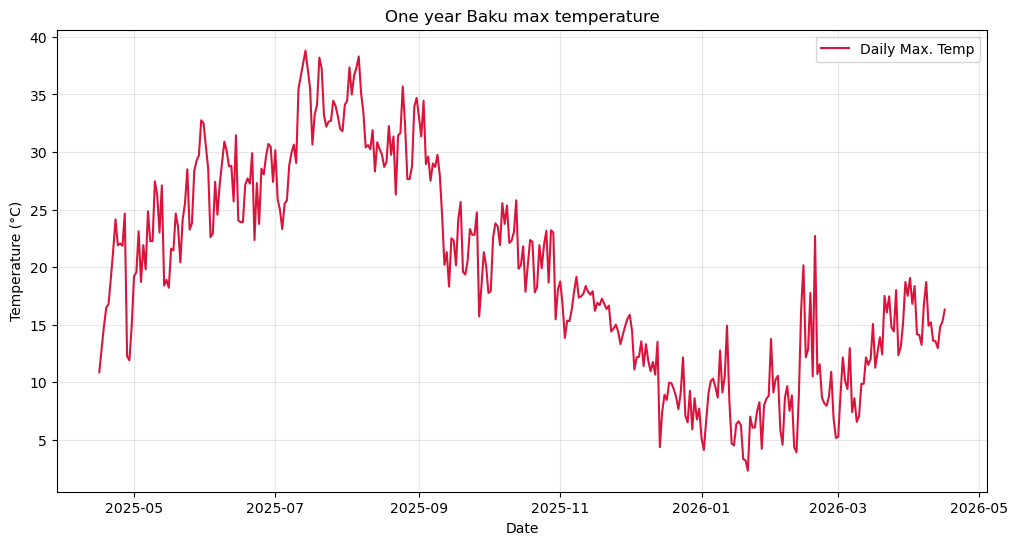

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['temperature_2m_max'], label='Daily Max. Temp', color='crimson')

plt.title('One year Baku max temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. Highest Temperature (Peak Summer)
Period: July – August 2025

Description: This is when Baku experiences its maximum heat. During this timeframe, daily mean temperatures typically range between 28°C and 35°C.

Key Insight: If your data shows a value significantly above 40°C, it is likely a statistical anomaly (outlier).

2. Lowest Temperature (Peak Winter)
Period: January – February 2026

Description: The coldest days occur during these months. Temperatures usually drop to between 2°C and 7°C.

Key Insight: Any values below 0°C in your dataset represent the rare freezing periods or cold snaps in Baku.

In [13]:
import pandas as pd
from datetime import datetime, timedelta

# Get current date and calculate date for 7 days ahead
today = datetime.now()
future_end = today + timedelta(days=6)

# Define forecast parameters for Baku
forecast_params = {
    "latitude": 40.41,
    "longitude": 49.87,
    "daily": [
        "temperature_2m_mean",
        "et0_fao_evapotranspiration_sum",
        "sunshine_duration",
        "shortwave_radiation_sum",
        "relative_humidity_2m_mean",
        "surface_pressure_mean",
        "precipitation_sum",
        "precipitation_hours",
        "wind_speed_10m_max",
        "cloud_cover_mean",
        "wind_gusts_10m_mean",
        "temperature_2m_max" 
    ],
    "timezone": "auto"
}

# Requesting the Open-Meteo forecast endpoint
forecast_resp = openmeteo.weather_api(
    "https://api.open-meteo.com/v1/forecast", 
    params=forecast_params
)
fcast = forecast_resp[0].Daily()

# Creating the DataFrame from the API response
df_future = pd.DataFrame({
    "date": pd.date_range(
        start=pd.to_datetime(fcast.Time(), unit="s", utc=True),
        end=pd.to_datetime(fcast.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=fcast.Interval()),
        inclusive="left"
    ),
    "temperature_2m_mean":           fcast.Variables(0).ValuesAsNumpy(),
    "et0_fao_evapotranspiration_sum": fcast.Variables(1).ValuesAsNumpy(),
    "sunshine_duration":              fcast.Variables(2).ValuesAsNumpy(),
    "shortwave_radiation_sum":        fcast.Variables(3).ValuesAsNumpy(),
    "relative_humidity_2m_mean":      fcast.Variables(4).ValuesAsNumpy(),
    "surface_pressure_mean":          fcast.Variables(5).ValuesAsNumpy(),
    "precipitation_sum":              fcast.Variables(6).ValuesAsNumpy(),
    "precipitation_hours":            fcast.Variables(7).ValuesAsNumpy(),
    "wind_speed_10m_max":             fcast.Variables(8).ValuesAsNumpy(),
    "cloud_cover_mean":               fcast.Variables(9).ValuesAsNumpy(),
    "wind_gusts_10m_mean":            fcast.Variables(10).ValuesAsNumpy(),
    "temperature_2m_max":             fcast.Variables(11).ValuesAsNumpy()
})

# Display the first 7 days of the forecast
print(df_future.head(7))

                       date  temperature_2m_mean  \
0 2026-04-19 20:00:00+00:00            13.323418   
1 2026-04-20 20:00:00+00:00            10.408834   
2 2026-04-21 20:00:00+00:00            12.633835   
3 2026-04-22 20:00:00+00:00            13.173416   
4 2026-04-23 20:00:00+00:00            12.958835   
5 2026-04-24 20:00:00+00:00            12.283551   
6 2026-04-25 20:00:00+00:00            12.841249   

   et0_fao_evapotranspiration_sum  sunshine_duration  shortwave_radiation_sum  \
0                        2.032600        1094.332397                 7.390000   
1                        1.401618        4967.534668                 7.060000   
2                        3.017547       44194.984375                21.040001   
3                        2.413235       36546.726562                15.370000   
4                        3.362634       43739.703125                23.070000   
5                        2.770368       42081.664062                19.740000   
6               

### Weather Variables Documentation

| Variable | Description | Unit |
| :--- | :--- | :--- |
| **`temperature_2m_mean`** | Mean air temperature at 2 meters above the ground. | °C |
| **`temperature_2m_max`** | Maximum daily air temperature at 2 meters above the ground. | °C |
| **`et0_fao_evapotranspiration_sum`** | Reference evapotranspiration (FAO-56 Penman-Monteith). | mm |
| **`sunshine_duration`** | Number of seconds of sunshine per day. | Seconds (s) |
| **`shortwave_radiation_sum`** | Total daily solar radiation on a horizontal surface. | $MJ/m^2$ |
| **`relative_humidity_2m_mean`** | Average relative humidity at 2 meters above the ground. | % |
| **`surface_pressure_mean`** | Average atmospheric pressure at the surface level. | hPa |
| **`precipitation_sum`** | Sum of daily precipitation (rain, snow, etc.). | mm |
| **`precipitation_hours`** | Number of hours with precipitation. | Hours (h) |
| **`wind_speed_10m_max`** | Maximum wind speed at 10 meters above the ground. | km/h |
| **`wind_gusts_10m_mean`** | Average wind gusts at 10 meters above the ground. | km/h |
| **`cloud_cover_mean`** | Average cloud cover as a percentage of the sky. | % |
| **`soil_moisture_0_to_7cm_mean`** | Average water content in the soil (0-7 cm depth). | $m^3/m^3$ |

### Task 3 — City & Variable Selection

Choose your 3+ cities and document:

| City | Latitude | Longitude | Why this city? |
|------|----------|-----------|----------------|
| Baku | 40.41 | 49.87 | Home city, local relevance |
| ... | ... | ... | ... |

Choose at least **6 daily weather variables** you will track. For each variable, note: name, unit, and why it is relevant to your analysis.


### 1. Saatli Station Metadata
| Field | Value |
| :--- | :--- |
| **Latitude** | 39.93 |
| **Longitude** | 48.37 |
| **Target Crop** | Cotton |
| **Climate Zone** | Arid (Dry) |

### 2. Lankaran Station Metadata
| Field | Value |
| :--- | :--- |
| **Latitude** | 38.75 |
| **Longitude** | 48.85 |
| **Target Crop** | Tea |
| **Climate Zone** | Humid (Subtropical) |

---

> **Note:** Additional cities and agricultural zones will be added in the future to expand the scope and accuracy of the soil moisture prediction model.

### Task 4 — Project Plan

Update the `README.md` in your fork with:

- **Problem statement**: What question will your prediction model try to answer?
- **Data sources**: Which API endpoints and parameters you will use
- **Cities and variables**: Your selections from Task 3
- **Methodology outline**: High-level approach for each week
- **Success criteria**: How will you evaluate your pipeline and your model?

In [ ]:
#UPDATED